In [1]:
# in this notebook, we load two cluster assignments, create dictionaries using the shared examples only based on their keys, and measure their similarities.

In [1]:
# let's load a few important packages for checking the cluster similarities
import numpy as np
import pandas as pd
import os
import sys
import json
from collections import Counter
import re
# from sklearn.metrics import adjusted_rand_score
# from sklearn.metrics import normalized_mutual_info_score
# from sklearn.metrics import adjusted_mutual_info_score
# from sklearn.metrics import fowlkes_mallows_score
# from sklearn.metrics import silhouette_score
# from sklearn.metrics import calinski_harabasz_score
# from sklearn.metrics import davies_bouldin_score
# from sklearn.metrics import pairwise_distances
# from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import csv

import geopandas as gpd

In [2]:
# let's load the target/ground-truth cluster assignments. it's in `root_id_type_dict.pkl` file.
import pickle
root_id_type_dict = pickle.load(open('locationid_borough_dict.pkl', 'rb'))

In [3]:
from scipy.sparse import load_npz

adj = load_npz('sparse_connectivity_matrix_taxi.npz')
print(adj.shape)

(259, 259)


In [ ]:
a = set(root_id_type_dict.values())
a

In [4]:
import json

with open('root_id_to_index_mapping_taxi.json') as f:
    id_to_index = json.load(f)

# 反转 mapping
index_to_id = {v: int(k) for k, v in id_to_index.items()}

# 看前几个
for i in range(10):
    print(i, "→ LocationID:", index_to_id[i])

0 → LocationID: 234
1 → LocationID: 186
2 → LocationID: 164
3 → LocationID: 50
4 → LocationID: 162
5 → LocationID: 229
6 → LocationID: 114
7 → LocationID: 143
8 → LocationID: 161
9 → LocationID: 142


In [5]:
import geopandas as gpd

# download at https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip
zones = gpd.read_file("taxi_zones/taxi_zones.shp")
print(zones.head())

   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...  
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...  
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...  
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...  
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...  


<Axes: >

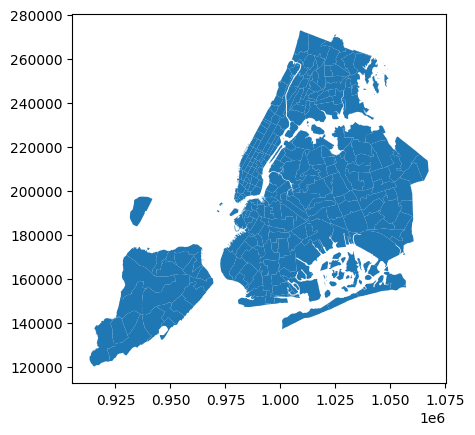

In [6]:
zones.plot()

In [ ]:
# shapefile
zones = gpd.read_file("taxi_zones/taxi_zones.shp")

In [ ]:
sbm_cluster_assignment_dict = np.load('sbm_runs_taxi/sbm_0/cluster_assignment_dict.npy', allow_pickle=True).item()

In [ ]:
len(sbm_cluster_assignment_dict)

In [ ]:
print(type(sbm_cluster_assignment_dict))
print(len(sbm_cluster_assignment_dict))
print(list(sbm_cluster_assignment_dict.items())[:10])

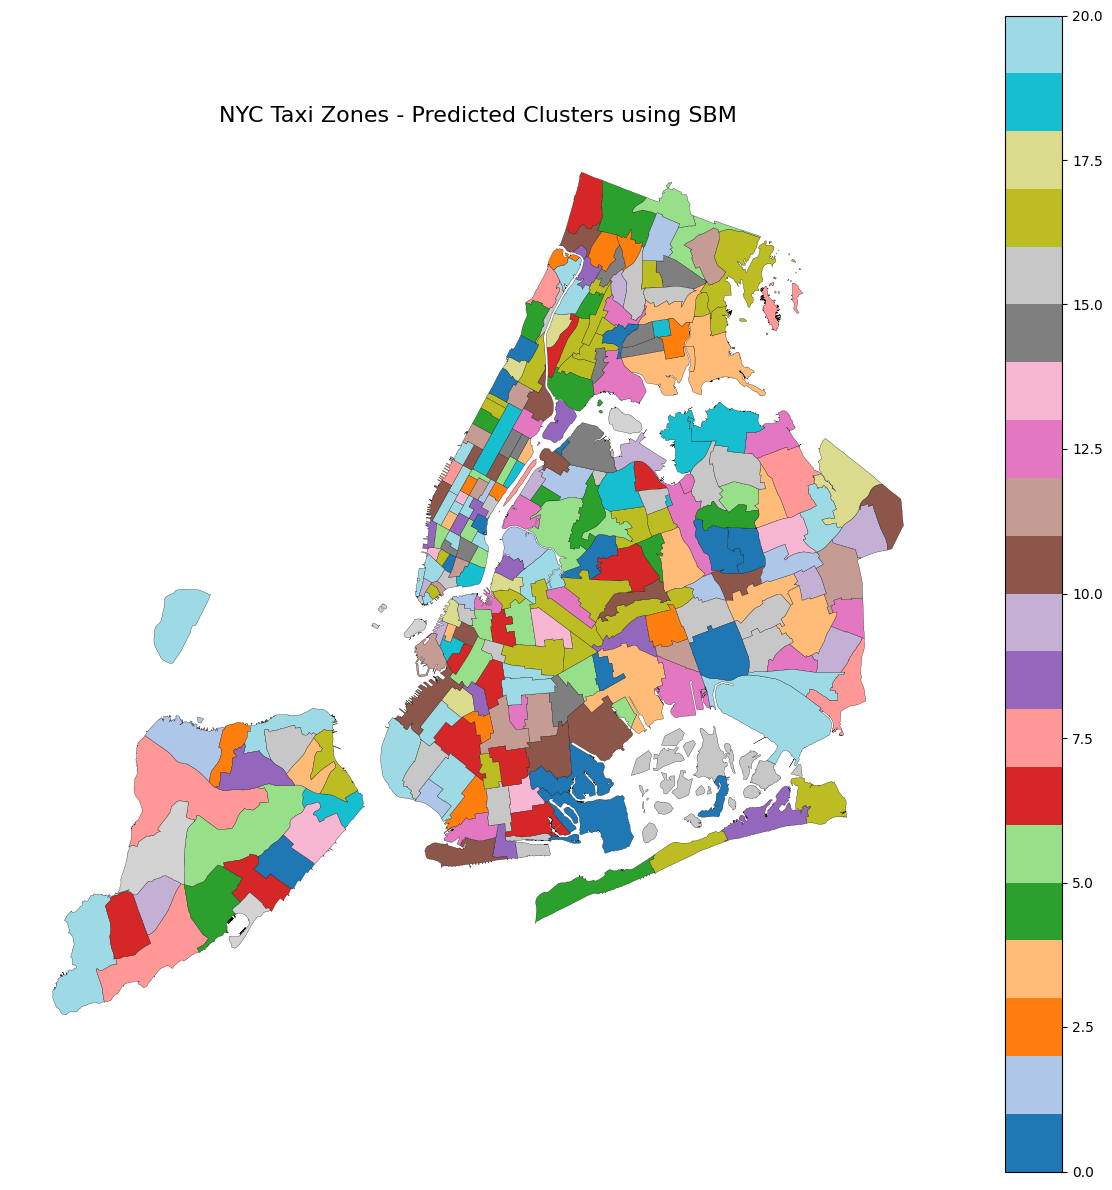

In [24]:
# 1.Read clusters
sbm_cluster_assignment_dict = np.load('sbm_runs_taxi/sbm_0/cluster_assignment_dict.npy', allow_pickle=True).item()

# 2. dict → dataframe
cluster_df = pd.DataFrame({
    "LocationID": list(sbm_cluster_assignment_dict.keys()),
    "predicted_cluster": list(sbm_cluster_assignment_dict.values())
})

# 3. merge
map_df = zones.merge(cluster_df, on="LocationID", how="left")

# 4. plot
fig, ax = plt.subplots(figsize=(12, 12))

map_df.plot(
    column="predicted_cluster",
    cmap="tab20",
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    missing_kwds={"color": "lightgrey", "label": "Not used"},
    ax=ax
)

ax.set_title("NYC Taxi Zones - Predicted Clusters using SBM", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
print("Total zones in shapefile:", len(zones))
print("Clusters assigned:", len(cluster_df))
print("Missing zones:", map_df["predicted_cluster"].isna().sum())

Total zones in shapefile: 263
Clusters assigned: 259
Missing zones: 6


In [15]:
missing = map_df[map_df["predicted_cluster"].isna()]
print(missing[["LocationID", "zone", "borough"]])

     LocationID                                           zone        borough
98           99                                Freshkills Park  Staten Island
102         103  Governor's Island/Ellis Island/Liberty Island      Manhattan
103         104  Governor's Island/Ellis Island/Liberty Island      Manhattan
104         105  Governor's Island/Ellis Island/Liberty Island      Manhattan
109         110                               Great Kills Park  Staten Island
198         199                                  Rikers Island          Bronx


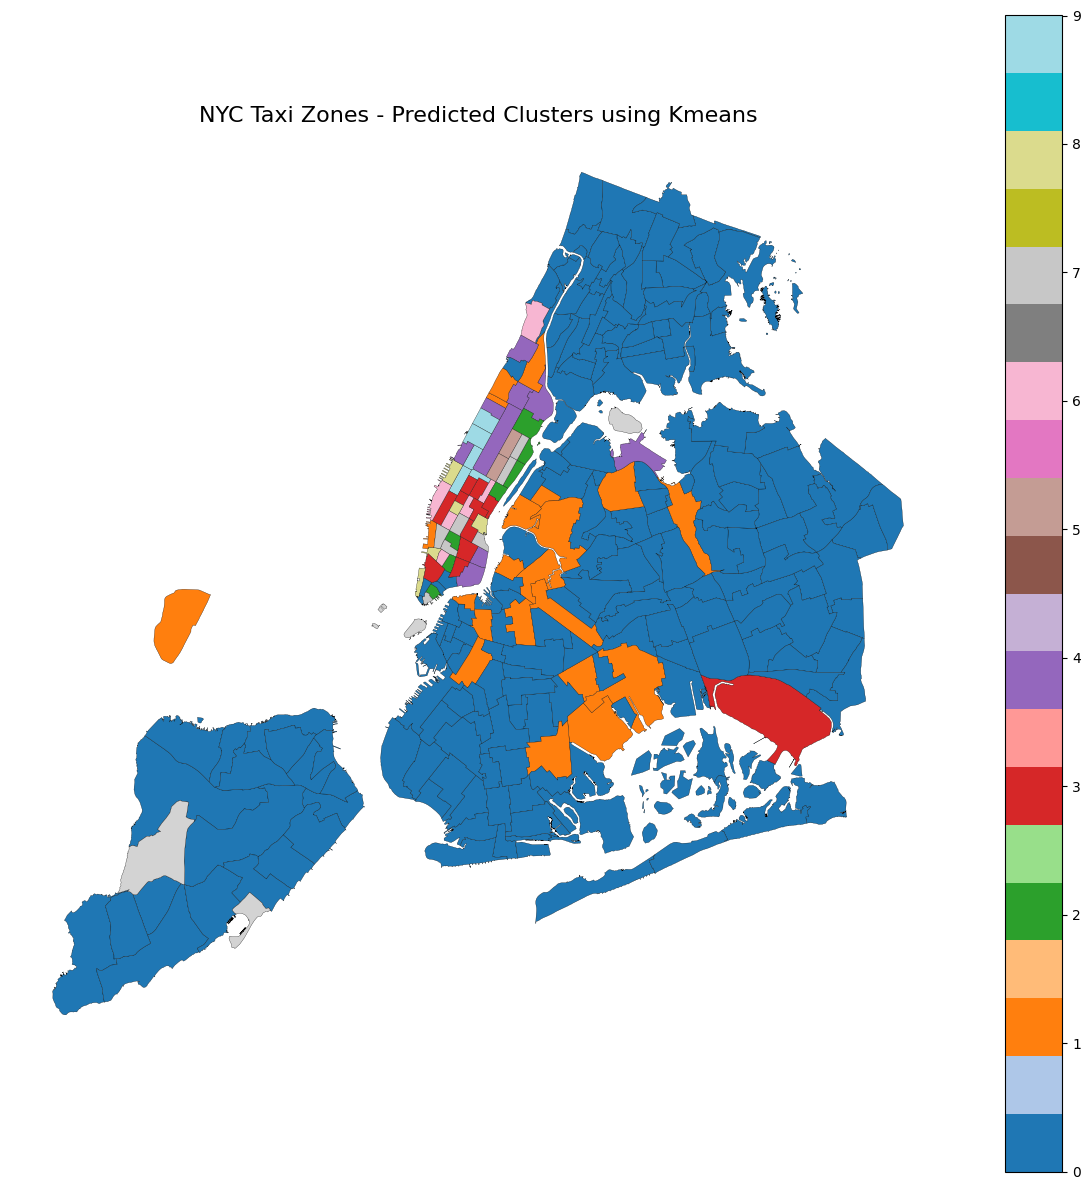

In [27]:
# 1.Read clusters
kmeans_cluster_assignment_dict = np.load('kmeans_runs_taxi/pca_cluster_assignment_dict_tuned_0.npy', allow_pickle=True).item()

# 2. dict → dataframe
cluster_df = pd.DataFrame({
    "LocationID": list(kmeans_cluster_assignment_dict.keys()),
    "predicted_cluster": list(kmeans_cluster_assignment_dict.values())
})
cluster_df["LocationID"] = cluster_df["LocationID"].astype(int)
# 3. merge
map_df = zones.merge(cluster_df, on="LocationID", how="left")

# 4. plot
fig, ax = plt.subplots(figsize=(12, 12))

map_df.plot(
    column="predicted_cluster",
    cmap="tab20",
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    missing_kwds={"color": "lightgrey", "label": "Not used"},
    ax=ax
)

ax.set_title("NYC Taxi Zones - Predicted Clusters using Kmeans", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

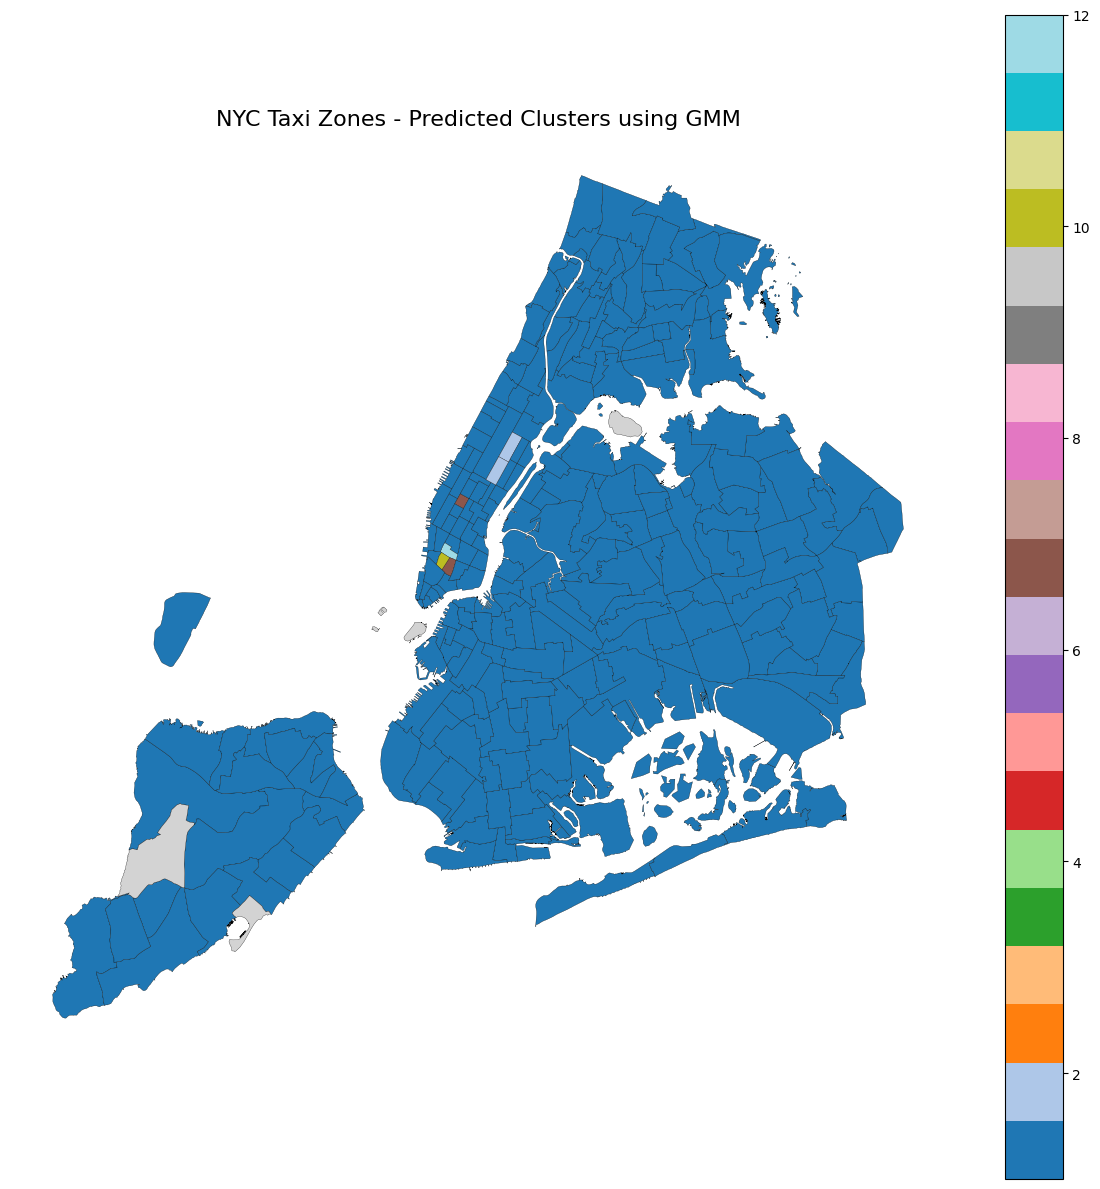

In [37]:
# 1.Read clusters
gmm_cluster_assignment_dict = np.load('gmm_runs_taxi/vmog_cluster_assignment_dict_tuned_5.npy', allow_pickle=True).item()

# 2. dict → dataframe
cluster_df = pd.DataFrame({
    "LocationID": list(gmm_cluster_assignment_dict.keys()),
    "predicted_cluster": list(gmm_cluster_assignment_dict.values())
})
cluster_df["LocationID"] = cluster_df["LocationID"].astype(int)
# 3. merge
map_df = zones.merge(cluster_df, on="LocationID", how="left")

# 4. plot
fig, ax = plt.subplots(figsize=(12, 12))

map_df.plot(
    column="predicted_cluster",
    cmap="tab20",
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    missing_kwds={"color": "lightgrey", "label": "Not used"},
    ax=ax
)

ax.set_title("NYC Taxi Zones - Predicted Clusters using GMM", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

In [36]:
import numpy as np
kmeans_cluster_assignment_dict = np.load('kmeans_runs_taxi/pca_cluster_assignment_dict_tuned_0.npy', allow_pickle=True).item()
clusters = list(kmeans_cluster_assignment_dict.values())
print(len(np.unique(clusters)))

10
